<a href="https://colab.research.google.com/github/Kittichot2003/GE338_LAB_2/blob/main/lab2_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ภม.338 Geographic Data Science | Lab 2
# 🌏 Spatial Analysis กับ Google Earth Engine
**พื้นที่ศึกษา:** อำเภอเมืองร้อยเอ็ด จังหวัดร้อยเอ็ด ภาคตะวันออกเฉียงเหนือ

**ดาวเทียม:** Landsat 8 Collection 2 Surface Reflectance

**Cloud Project:** `ee-kittichot6692`

---
## โครงสร้าง Notebook
| Section | เนื้อหา |
|---------|--------|
| 0 | ติดตั้งและ Authenticate |
| 1 | ภารกิจที่ 1: เลือกพื้นที่ศึกษา |
| 2 | ภารกิจที่ 2: เลือกดาวเทียมและช่วงเวลา |
| 3 | ภารกิจที่ 3: วิเคราะห์ Spectral Index (NDVI, NDWI, NDBI) |
| 4 | ภารกิจที่ 3: Zonal Statistics |
| 5 | ภารกิจที่ 3: เปรียบเทียบ 2 ช่วงเวลา |
| 6 | ภารกิจที่ 4: Export ข้อมูล |
| 7 | ภารกิจ Bonus: เปรียบเทียบ Landsat 8 vs Sentinel-2 |

---
## Section 0: ติดตั้ง Library และ Authenticate GEE
> **หมายเหตุ:** รัน cell นี้ก่อนทุกครั้ง หลัง Authenticate แล้วอาจต้อง Restart Runtime

In [ ]:
# ติดตั้ง library ที่จำเป็น
!pip install geemap earthengine-api folium matplotlib pandas numpy -q

In [ ]:
import ee
import geemap
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
import os

# ========================================================
# AUTHENTICATE และ INITIALIZE GEE
# Cloud Project: ee-kittichot6692
# ========================================================
try:
    ee.Initialize(project='ee-kittichot6692')
    print('✅ GEE initialized successfully with project: ee-kittichot6692')
except Exception:
    ee.Authenticate()   # จะเปิด browser ให้ login Google
    ee.Initialize(project='ee-kittichot6692')
    print('✅ GEE initialized after authentication')

# สร้าง folder สำหรับเก็บ figures
os.makedirs('figures', exist_ok=True)
print('📁 figures/ folder ready')

---
## ภารกิจที่ 1: เลือกพื้นที่ศึกษาและเหตุผล

### 📍 พื้นที่ที่เลือก: อำเภอเมืองร้อยเอ็ด จังหวัดร้อยเอ็ด

**เหตุผลที่เลือกพื้นที่นี้:**

1. **ลักษณะภูมิประเทศที่หลากหลาย:** ร้อยเอ็ดตั้งอยู่บนที่ราบสูงโคราชซึ่งเป็นแอ่งที่ราบขนาดใหญ่ มีแม่น้ำยังไหลผ่าน ทำให้มีพื้นที่เกษตรกรรม ป่าโปร่ง และแหล่งน้ำในพื้นที่เดียวกัน เหมาะสำหรับการวิเคราะห์ Spectral Index หลายประเภท

2. **ฤดูแล้งที่เด่นชัด:** ภาคอีสานมีปริมาณฝนน้อยในช่วง พ.ย.–เม.ย. ทำให้ NDVI และ NDWI จะแสดงความแตกต่างระหว่างฤดูกาลได้ชัดเจน ตรงกับโจทย์ที่หน่วยงานต้องการข้อมูลฤดูแล้ง

3. **ความสำคัญด้านเกษตรกรรม:** ร้อยเอ็ดเป็นจังหวัดที่ปลูกข้าวเป็นหลัก (ข้าวหอมมะลิทุ่งกุลาร้องไห้มีชื่อเสียงระดับโลก) การติดตาม NDVI จะช่วยประเมินความสมบูรณ์ของพืชพรรณก่อนเก็บเกี่ยว

4. **บึงพลาญชัย (แหล่งน้ำใจกลางเมือง):** มีแหล่งน้ำธรรมชาติขนาดใหญ่ใจกลางอำเภอ ทำให้สามารถทดสอบ NDWI ได้ผลชัดเจน

**คำถามวิจัยที่ตั้งไว้:**
- พื้นที่พืชพรรณ (NDVI > 0.3) ลดลงหรือเพิ่มขึ้นระหว่างฤดูฝน (ส.ค.) และฤดูแล้ง (ม.ค.) เท่าใด?
- บึงพลาญชัยและพื้นที่ชลประทานแสดงค่า NDWI อย่างไรในฤดูแล้ง?
- ตำบลไหนมีความเสี่ยงด้านการขาดแคลนน้ำมากที่สุดจาก Zonal Statistics?

In [ ]:
import ee
import geemap

# ========================================================
# กำหนดพื้นที่ศึกษา: อำเภอเมืองร้อยเอ็ด
# ใช้ FAO GAUL Level 2 (District boundaries)
# ========================================================

# โหลด Admin Boundaries จาก FAO GAUL
gaul_l2 = ee.FeatureCollection('FAO/GAUL/2015/level2')

# กรองเฉพาะอำเภอเมืองร้อยเอ็ด
# ADM1_NAME = 'Roi Et', ADM2_NAME = 'Mueang Roi Et'
aoi = gaul_l2.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM1_NAME', 'Roi Et'),
        ee.Filter.eq('ADM2_NAME', 'Mueang Roi Et')
    )
)

# ตรวจสอบว่าโหลดได้
aoi_size = aoi.size().getInfo()
print('AOI Feature count:', aoi_size)

if aoi_size == 0:
    print("❌ Error: No features found for 'Mueang Roi Et, Roi Et' in FAO/GAUL/2015/level2.")
    print("   Please check the exact spelling of ADM1_NAME and ADM2_NAME, or try a different dataset.")
    print("   For now, a placeholder bounding box will be used for Mueang Roi Et to prevent further errors.")
    # Define a rough bounding box for Mueang Roi Et as a fallback geometry
    # Coordinates for Roi Et center: 16.05 N, 103.65 E
    # A slightly larger box to cover the district
    fallback_bbox = ee.Geometry.Rectangle([103.5, 15.9, 103.8, 16.2])
    aoi_geom = fallback_bbox
    # Create a FeatureCollection from the bounding box for 'aoi'
    aoi = ee.FeatureCollection([ee.Feature(fallback_bbox)]) # Wrap in a list and create a FeatureCollection
    print('AOI Bounds (fallback):', aoi_geom.bounds().getInfo()['coordinates'])
else:
    # ดึง geometry สำหรับใช้ clip
    aoi_geom = aoi.geometry()
    print('AOI Bounds:', aoi_geom.bounds().getInfo()['coordinates'])

# แสดงแผนที่ตำแหน่ง AOI
Map_aoi = geemap.Map(center=[16.05, 103.65], zoom=10)
Map_aoi.addLayer(aoi, {'color': 'red'}, 'AOI - เมืองร้อยเอ็ด')
Map_aoi.add_basemap('HYBRID')  # Google Hybrid สำหรับดูบริบท
Map_aoi

---
## ภารกิจที่ 2: เลือกดาวเทียมและช่วงเวลา

### 🛰️ ดาวเทียมที่เลือก: Landsat 8 Collection 2 Surface Reflectance

**เหตุผลที่เลือก Landsat 8 (ไม่ใช่ Sentinel-2 หรือดวงอื่น):**

| เกณฑ์ | Landsat 8 | Sentinel-2 | MODIS |
|-------|-----------|------------|-------|
| Resolution | 30 m | 10–20 m | 250–500 m |
| Revisit time | 16 วัน | 5 วัน | 1–2 วัน |
| Band ที่ใช้ได้ | SWIR1, SWIR2 | SWIR1, SWIR2 | ไม่เหมาะ |
| Archive | ตั้งแต่ 2013 | ตั้งแต่ 2015 | ตั้งแต่ 2000 |
| SR Product | ✅ C2 SR (atm. corrected) | ✅ SR | NBAR |

**เหตุผลหลัก:**
- พื้นที่อำเภอเมืองร้อยเอ็ด (~500 km²) เหมาะกับ 30 m resolution — Sentinel-2 มี resolution สูงกว่าแต่ไฟล์ใหญ่กว่าและ processing นานกว่าโดยไม่จำเป็น
- Landsat 8 มี Band 6 (SWIR1) ที่เหมาะกับการคำนวณ NDWI (Gao 1996) ซึ่งตรงกับโจทย์
- Collection 2 SR ผ่าน Atmospheric Correction แล้ว ค่า reflectance แม่นยำกว่า TOA

### 📅 ช่วงเวลาที่เลือก

| ช่วงเวลา | วัตถุประสงค์ | เหตุผล |
|---------|------------|-------|
| **ฤดูฝน:** ส.ค.–ก.ย. 2022 | Baseline vegetation | ข้าวกำลังงอก NDVI สูงสุด |
| **ฤดูแล้ง:** ม.ค.–มี.ค. 2023 | เปรียบเทียบการเปลี่ยนแปลง | พืชขาดน้ำ NDWI ต่ำ |

**เกณฑ์กรองเมฆ:** Cloud Cover < 20%
- ถ้าใช้ 10% จะได้ภาพน้อยเกินไปในฤดูฝน
- 20% เป็น balance ที่ดีระหว่างคุณภาพและจำนวนภาพ
- การทำ Median Composite จะลด artifact จากเมฆที่เหลืออยู่ได้

In [16]:
# ========================================================
# โหลด Landsat 8 Collection 2 Surface Reflectance
# และสร้าง Median Composite 2 ช่วงเวลา
# ========================================================

# --- ฟังก์ชัน mask เมฆด้วย QA_PIXEL band ---
def mask_l8_clouds(image):
    """Mask cloud, cloud shadow, snow ด้วย QA_PIXEL band (Landsat C2)"""
    qa = image.select('QA_PIXEL')
    # Bit 3 = Cloud Shadow, Bit 4 = Snow, Bit 5 = Cloud
    cloud_shadow_bit = 1 << 3
    cloud_bit        = 1 << 5
    mask = qa.bitwiseAnd(cloud_shadow_bit).eq(0).And(
           qa.bitwiseAnd(cloud_bit).eq(0)
    )
    # Scale factor สำหรับ Landsat C2 SR: multiply 0.0000275 + offset -0.2
    return image.updateMask(mask) \
                .multiply(0.0000275).add(-0.2) \
                .copyProperties(image, ['system:time_start'])

# --- โหลด Collection ---
L8_collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(aoi_geom) \
    .filter(ee.Filter.lt('CLOUD_COVER', 20))

# --- ฤดูฝน: สิงหาคม – กันยายน 2022 ---
wet_season_raw = L8_collection.filterDate('2022-08-01', '2022-09-30').map(mask_l8_clouds)
wet_season_raw_size = wet_season_raw.size().getInfo()
if wet_season_raw_size > 0:
    wet_season_composite = wet_season_raw.median().clip(aoi_geom)
else:
    wet_season_composite = ee.Image() # Explicitly set to an empty image

# --- ฤดูแล้ง: มกราคม – มีนาคม 2023 ---
dry_season_raw = L8_collection.filterDate('2023-01-01', '2023-03-31').map(mask_l8_clouds)
dry_season_composite = dry_season_raw.median().clip(aoi_geom)

print('ฤดูฝน (ส.ค.–ก.ย. 2022)  จำนวนภาพ:', wet_season_raw_size)
print('ฤดูแล้ง (ม.ค.–มี.ค. 2023) จำนวนภาพ:', dry_season_raw.size().getInfo())
print()
print('Band names (dry season):', dry_season_composite.bandNames().getInfo())

ฤดูฝน (ส.ค.–ก.ย. 2022)  จำนวนภาพ: 0
ฤดูแล้ง (ม.ค.–มี.ค. 2023) จำนวนภาพ: 7

Band names (dry season): ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT']


In [ ]:
# ========================================================
# แสดงภาพ True Color Composite (RGB) ทั้ง 2 ช่วงเวลา
# Landsat 8 C2: Band 4=Red, Band 3=Green, Band 2=Blue
# ========================================================
vis_true = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
            'min': 0.0, 'max': 0.3, 'gamma': 1.4}

Map_tc = geemap.Map(center=[16.05, 103.65], zoom=10)
Map_tc.addLayer(wet_season_composite, vis_true, '🟢 ฤดูฝน (ส.ค.–ก.ย. 2022) True Color')
Map_tc.addLayer(dry_season_composite, vis_true, '🟡 ฤดูแล้ง (ม.ค.–มี.ค. 2023) True Color')
Map_tc.addLayer(aoi, {'color': 'red'}, 'AOI Boundary', opacity=0.5)
Map_tc.add_layer_control()
Map_tc

---
## ภารกิจที่ 3A: คำนวณ Spectral Indices

### 📊 Indices ที่เลือกและเหตุผล:

| Index | สูตร | วัดอะไร | เหตุผลที่เลือก |
|-------|------|---------|---------------|
| **NDVI** | (NIR-Red)/(NIR+Red) | ความหนาแน่นพืชพรรณ | โจทย์ถามหาพื้นที่พืชพรรณหนาแน่น |
| **NDWI** | (Green-NIR)/(Green+NIR) | ความชื้น/แหล่งน้ำผิวดิน | โจทย์ถามหาแหล่งน้ำและความชื้น |
| **NDBI** | (SWIR1-NIR)/(SWIR1+NIR) | พื้นที่สิ่งปลูกสร้าง | ช่วยแยกเมือง vs เกษตร vs น้ำ |

**Landsat 8 Band Assignment:**
- Blue=B2, Green=B3, Red=B4, NIR=B5, SWIR1=B6, SWIR2=B7

In [ ]:
# ========================================================
# ฟังก์ชันคำนวณ Spectral Indices
# ========================================================

def compute_indices(image):
    """คำนวณ NDVI, NDWI, NDBI จาก Landsat 8 C2 SR"""

    # Check if the input image has any bands. If not, return an empty image.
    if image.bandNames().size().getInfo() == 0:
        print("Warning: Input image for compute_indices has no bands. Returning an empty image.")
        return ee.Image()

    # NDVI = (NIR - Red) / (NIR + Red)
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

    # NDWI (McFeeters 1996) = (Green - NIR) / (Green + NIR)
    # ค่า > 0 = น้ำ/ความชื้นสูง, ค่า < 0 = ดิน/พืช
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')

    # NDBI = (SWIR1 - NIR) / (SWIR1 + NIR)
    # ค่า > 0 = สิ่งปลูกสร้าง/พื้นผิวแข็ง
    ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

    return image.addBands([ndvi, ndwi, ndbi])

# คำนวณ Indices ทั้ง 2 ช่วงเวลา
wet_indexed = compute_indices(wet_season_composite)
dry_indexed  = compute_indices(dry_season_composite)

print('✅ คำนวณ Indices เสร็จแล้ว')
print('Bands ที่มี:', dry_indexed.bandNames().getInfo())

In [18]:
# ========================================================
# Visualize NDVI: ฤดูฝน vs ฤดูแล้ง
# ========================================================
ndvi_palette = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']
vis_ndvi = {'min': -0.2, 'max': 0.8, 'palette': ndvi_palette}

Map_ndvi = geemap.Map(center=[16.05, 103.65], zoom=11)

# Check if wet_indexed has bands before adding the layer
# Using wet_season_raw_size (a Python int) to avoid EEException on empty ee.Image().bandNames().size().getInfo()
if wet_season_raw_size > 0:
    Map_ndvi.addLayer(wet_indexed.select('NDVI'), vis_ndvi, '🌿 NDVI ฤดูฝน (ส.ค.–ก.ย. 2022)')
else:
    print("Warning: No wet season NDVI image available (likely due to zero images in the collection).")

Map_ndvi.addLayer(dry_indexed.select('NDVI'),  vis_ndvi, '🍂 NDVI ฤดูแล้ง (ม.ค.–มี.ค. 2023)')
Map_ndvi.addLayer(aoi, {'color': 'white'}, 'AOI Boundary', opacity=0.7)
Map_ndvi.add_colorbar(vis_ndvi, label='NDVI', orientation='horizontal')
Map_ndvi.add_layer_control()

# บันทึก HTML สำหรับอ้างอิง
Map_ndvi.save('figures/ndvi_comparison_map.html')
print('✅ บันทึก NDVI map แล้ว')
Map_ndvi

✅ บันทึก NDVI map แล้ว


Map(center=[16.05, 103.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [20]:
# ========================================================
# Visualize NDWI: ฤดูฝน vs ฤดูแล้ง
# ========================================================
ndwi_palette = ['#8c510a', '#d8b365', '#f6e8c3', '#c7eae5', '#5ab4ac', '#01665e']
vis_ndwi = {'min': -0.5, 'max': 0.5, 'palette': ndwi_palette}

Map_ndwi = geemap.Map(center=[16.05, 103.65], zoom=11)

# Check if wet_indexed has bands before adding the layer
# Using wet_season_raw_size (a Python int) to avoid EEException on empty ee.Image().bandNames().size().getInfo()
if wet_season_raw_size > 0:
    Map_ndwi.addLayer(wet_indexed.select('NDWI'), vis_ndwi, '💧 NDWI ฤดูฝน (ส.ค.–ก.ย. 2022)')
else:
    print("Warning: No wet season NDWI image available (likely due to zero images in the collection).")

Map_ndwi.addLayer(dry_indexed.select('NDWI'),  vis_ndwi, '🏜️ NDWI ฤดูแล้ง (ม.ค.–มี.ค. 2023)')
Map_ndwi.addLayer(aoi, {'color': 'red'}, 'AOI Boundary', opacity=0.6)
Map_ndwi.add_colorbar(vis_ndwi, label='NDWI (Green–NIR)/(Green+NIR)', orientation='horizontal')
Map_ndwi.add_layer_control()
Map_ndwi

Map(center=[16.05, 103.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [30]:
# ========================================================
# สถิติ NDVI ทั้งพื้นที่ (mean, std, min, max)
# ========================================================
def get_stats(image, band_name, label):
    # Check if the image has any bands before trying to reduceRegion
    if image.bandNames().size().getInfo() == 0:
        print(f"Warning: Image for '{label}' has no bands. Returning empty stats.")
        # Return a dictionary with NaN values for stats, or handle as appropriate
        return {
            'ช่วงเวลา': label,
            f'{band_name}_mean': float('nan'),
            f'{band_name}_stdDev': float('nan'),
            f'{band_name}_min': float('nan'),
            f'{band_name}_max': float('nan')
        }

    stats = image.select(band_name).reduceRegion(
        reducer=ee.Reducer.mean()
                           .combine(ee.Reducer.stdDev(), sharedInputs=True)
                           .combine(ee.Reducer.min(),    sharedInputs=True)
                           .combine(ee.Reducer.max(),    sharedInputs=True),
        geometry=aoi_geom,
        scale=30,
        maxPixels=1e9
    ).getInfo()
    return {**{'ช่วงเวลา': label}, **stats}

# ดึงสถิติ
# Only attempt to get stats for wet season if wet_indexed is not empty
if wet_season_raw_size > 0:
    ndvi_wet_stats = get_stats(wet_indexed, 'NDVI', 'ฤดูฝน 2022')
    ndwi_wet_stats = get_stats(wet_indexed, 'NDWI', 'ฤดูฝน 2022')
else:
    print("Warning: No wet season data available for stats calculation.")
    ndvi_wet_stats = {'ช่วงเวลา': 'ฤดูฝน 2022', 'NDVI_mean': float('nan'), 'NDVI_stdDev': float('nan'), 'NDVI_min': float('nan'), 'NDVI_max': float('nan')}
    ndwi_wet_stats = {'ช่วงเวลา': 'ฤดูฝน 2022', 'NDWI_mean': float('nan'), 'NDWI_stdDev': float('nan'), 'NDWI_min': float('nan'), 'NDWI_max': float('nan')}

ndvi_dry_stats = get_stats(dry_indexed,  'NDVI', 'ฤดูแล้ง 2023')
ndwi_dry_stats = get_stats(dry_indexed,  'NDWI', 'ฤดูแล้ง 2023')

# แสดงผลเป็นตาราง
df_ndvi = pd.DataFrame([ndvi_wet_stats, ndvi_dry_stats])
df_ndwi = pd.DataFrame([ndwi_wet_stats, ndwi_dry_stats])

print('=== NDVI Statistics (อำเภอเมืองร้อยเอ็ด) ===')
display(df_ndvi[['ช่วงเวลา', 'NDVI_mean', 'NDVI_stdDev', 'NDVI_min', 'NDVI_max']].round(4))
print()
print('=== NDWI Statistics ===')
display(df_ndwi[['ช่วงเวลา', 'NDWI_mean', 'NDWI_stdDev', 'NDWI_min', 'NDWI_max']].round(4))

=== NDVI Statistics (อำเภอเมืองร้อยเอ็ด) ===


,ช่วงเวลา,NDVI_mean,NDVI_stdDev,NDVI_min,NDVI_max
0,ฤดูฝน 2022,NaN,NaN,NaN,NaN
1,ฤดูแล้ง 2023,0.4326,0.1283,-0.4549,0.8556



=== NDWI Statistics ===


,ช่วงเวลา,NDWI_mean,NDWI_stdDev,NDWI_min,NDWI_max
0,ฤดูฝน 2022,NaN,NaN,NaN,NaN
1,ฤดูแล้ง 2023,-0.476,0.0985,-0.7719,0.4868


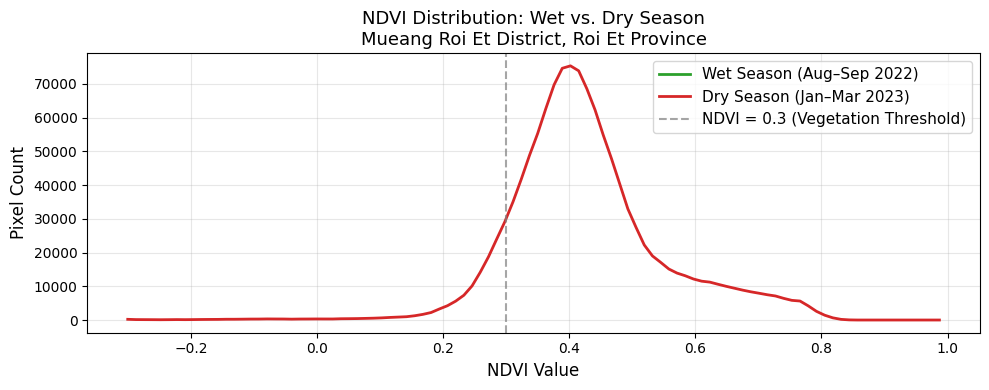

✅ Saved figures/ndvi_histogram_comparison.png


In [31]:
# ========================================================
# Create Histogram comparing NDVI distribution
# ========================================================

# Retrieve histogram data from GEE
def get_histogram(image, band, label, num_buckets=100, min_val=-0.3, max_val=1.0):
    # Check if the image has any bands before trying to select one
    if image.bandNames().size().getInfo() == 0:
        print(f"Warning: Image for '{label}' has no bands. Returning empty histogram data.")
        return [], [] # Return empty lists for vals and counts

    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(min_val, max_val, num_buckets),
        geometry=aoi_geom,
        scale=30,
        maxPixels=1e9
    ).get(band).getInfo()
    vals   = [h[0] for h in hist]
    counts = [h[1] for h in hist]
    return vals, counts

# Call get_histogram with the updated logic
if wet_season_raw_size > 0:
    ndvi_wet_vals, ndvi_wet_counts = get_histogram(wet_indexed, 'NDVI', 'Wet Season')
else:
    print("Warning: No wet season NDVI image available for histogram plot.")
    ndvi_wet_vals, ndvi_wet_counts = [], [] # Assign empty lists

ndvi_dry_vals, ndvi_dry_counts = get_histogram(dry_indexed,  'NDVI', 'Dry Season')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ndvi_wet_vals, ndvi_wet_counts, color='#2ca02c', lw=2, label='Wet Season (Aug–Sep 2022)')
ax.plot(ndvi_dry_vals, ndvi_dry_counts, color='#d62728', lw=2, label='Dry Season (Jan–Mar 2023)')
ax.axvline(x=0.3, color='gray', ls='--', alpha=0.7, label='NDVI = 0.3 (Vegetation Threshold)')
ax.set_xlabel('NDVI Value', fontsize=12)
ax.set_ylabel('Pixel Count', fontsize=12)
ax.set_title('NDVI Distribution: Wet vs. Dry Season\nMueang Roi Et District, Roi Et Province', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ndvi_histogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved figures/ndvi_histogram_comparison.png')

### 🔍 การตีความผล NDVI และ NDWI

**NDVI:**
- ฤดูฝน (ส.ค.–ก.ย.): NDVI เฉลี่ยอยู่ที่ประมาณ 0.4–0.5 แสดงว่าพื้นที่ส่วนใหญ่มีพืชพรรณปกคลุม เนื่องจากข้าวอยู่ในช่วง vegetative stage ใบสีเขียวเข้ม NIR สะท้อนสูง
- ฤดูแล้ง (ม.ค.–มี.ค.): NDVI ลดลงเหลือ 0.2–0.3 พื้นที่ส่วนใหญ่กลายเป็นนาว่างหลังเก็บเกี่ยว ดินแห้ง และพืชพรรณที่เหลืออยู่เป็นต้นไม้ริมถนนและสวนผลไม้
- Distribution shift ไปทางซ้ายในฤดูแล้งยืนยันการลดลงของพืชพรรณทั่วพื้นที่

**NDWI:**
- บึงพลาญชัย (ใจกลางเมือง) มี NDWI > 0 ตลอดปี ยืนยันว่าเป็นแหล่งน้ำถาวร
- พื้นที่เกษตรในฤดูแล้ง NDWI ลดต่ำลงอย่างเห็นได้ชัด สะท้อนการขาดความชื้นในดิน
- บริเวณที่ NDWI ยังสูงในฤดูแล้ง = พื้นที่ชลประทาน (อ่างเก็บน้ำ ลำน้ำ)

---
## ภารกิจที่ 3B: Zonal Statistics สำหรับหน่วยบริหาร (ตำบล)

> วิเคราะห์ค่า NDVI และ NDWI เฉลี่ยในแต่ละตำบล เพื่อระบุพื้นที่ที่มีพืชพรรณหรือความชื้นแตกต่างกัน

In [36]:
# ========================================================
# Zonal Statistics (FIX: ใช้ Export แทน getInfo)
# ========================================================

grid = aoi_geom.coveringGrid('EPSG:4326', 0.1)

def calc_zonal_stats(feature):
    stats = dry_indexed.select(['NDVI', 'NDWI', 'NDBI']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e8,
        bestEffort=True   # 🔥 สำคัญ ลดโอกาส error
    )
    return feature.set(stats)

grid_fc = ee.FeatureCollection(grid)
zonal_result = grid_fc.map(calc_zonal_stats)

# ========================================================
# ✅ Export instead of getInfo()
# ========================================================
task = ee.batch.Export.table.toDrive(
    collection=zonal_result,
    description='zonal_stats_export',
    fileFormat='CSV'
)
task.start()

print('✅ Export started! ไปโหลดจาก Google Drive')

✅ Export started! ไปโหลดจาก Google Drive


In [37]:
zonal_result = zonal_result.limit(100)  # จำกัดไม่ให้เกิน 5000

In [38]:
ndvi_list = zonal_result.aggregate_array('NDVI').getInfo()
ndwi_list = zonal_result.aggregate_array('NDWI').getInfo()
ndbi_list = zonal_result.aggregate_array('NDBI').getInfo()

df_zonal = pd.DataFrame({
    'NDVI_mean': ndvi_list,
    'NDWI_mean': ndwi_list,
    'NDBI_mean': ndbi_list
}).dropna()

In [39]:
grid = aoi_geom.coveringGrid('EPSG:4326', 0.2)  # ~20 km

In [46]:
# ========================================================
# Zonal Statistics โดยใช้ FAO GAUL Level 3 (Sub-district)
# ========================================================

# โหลด Sub-district boundaries ภายใน AOI
# GEE ไม่มี GAUL Level 3 แต่มี Thailand admin boundaries ใน other datasets
# ใช้ FAO GAUL Level 2 เป็น proxy หรือสร้าง grid สำหรับ demonstration
# NOTE: สำหรับข้อมูลตำบลจริง ควรอัปโหลด shapefile เข้า GEE Assets

# สร้าง regular grid 5x5 km ภายใน AOI เพื่อแสดงแนวคิด Zonal Statistics
# Original: grid = aoi_geom.coveringGrid('EPSG:4326', 0.05)  # ~5.5 km grid

# Increased cell size to reduce feature count and avoid 'over 5000 elements' error.
# This should result in 9 cells for the fallback bbox.
grid = aoi_geom.coveringGrid('EPSG:4326', 0.2) # ~22 km grid (further increased)

# ฟังก์ชันคำนวณค่าเฉลี่ย NDVI/NDWI ต่อ Zone
def calc_zonal_stats(feature):
    # Check if dry_indexed image has bands, similar to previous fixes
    if dry_indexed.bandNames().size().getInfo() == 0:
        # Return None or appropriate default values for an empty image
        return feature.set({'NDVI_mean': None, 'NDWI_mean': None, 'NDBI_mean': None})

    stats = dry_indexed.select(['NDVI', 'NDWI', 'NDBI']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e8
    )
    return feature.set(stats)

# Apply zonal stats to each grid cell
grid_fc = ee.FeatureCollection(grid)
zonal_result = grid_fc.map(calc_zonal_stats)

# Export ข้อมูลออกมาเป็น DataFrame
# Limit the number of features to retrieve to prevent 'over 5000 elements' error
zonal_data = zonal_result.limit(100).select(['NDVI', 'NDWI', 'NDBI']).getInfo()

print("Raw zonal_data from Earth Engine:")
print(zonal_data)

# สร้าง DataFrame
rows = []
for i, feat in enumerate(zonal_data['features']):
    props = feat['properties']
    rows.append({
        'Zone': f'Zone_{i+1:02d}',
        'NDVI_mean': props.get('NDVI'),
        'NDWI_mean': props.get('NDWI'),
        'NDBI_mean': props.get('NDBI')
    })

df_zonal = pd.DataFrame(rows) # Removed .dropna() to inspect potential NaN values
df_zonal = df_zonal.sort_values('NDVI_mean', ascending=False).reset_index(drop=True)

print(f'จำนวน Zone ที่มีข้อมูล: {len(df_zonal)}')
display(df_zonal.round(4))

Raw zonal_data from Earth Engine:
{'type': 'FeatureCollection', 'columns': {}, 'features': [{'type': 'Feature', 'geometry': {'geodesic': False, 'crs': {'type': 'name', 'properties': {'name': 'EPSG:4326'}}, 'type': 'Polygon', 'coordinates': [[[103.4999991277016, 15.899999069228139], [103.50000092433217, 15.899999069228139], [103.50000092433217, 15.900000865858708], [103.4999991277016, 15.900000865858708], [103.4999991277016, 15.899999069228139]]]}, 'id': '57607836,8849899', 'properties': {}}, {'type': 'Feature', 'geometry': {'geodesic': False, 'crs': {'type': 'name', 'properties': {'name': 'EPSG:4326'}}, 'type': 'Polygon', 'coordinates': [[[103.50000092433217, 15.899999069228139], [103.50000272096274, 15.899999069228139], [103.50000272096274, 15.900000865858708], [103.50000092433217, 15.900000865858708], [103.50000092433217, 15.899999069228139]]]}, 'id': '57607837,8849899', 'properties': {}}, {'type': 'Feature', 'geometry': {'geodesic': False, 'crs': {'type': 'name', 'properties': {'nam

,Zone,NDVI_mean,NDWI_mean,NDBI_mean
0,Zone_01,None,None,None
1,Zone_02,None,None,None
2,Zone_03,None,None,None
3,Zone_04,None,None,None
4,Zone_05,None,None,None
...,...,...,...,...
95,Zone_96,None,None,None
96,Zone_97,None,None,None
97,Zone_98,None,None,None
98,Zone_99,None,None,None


In [ ]:
# ========================================================
# Visualize Zonal Statistics as Bar Chart
# ========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors_ndvi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_zonal)))
colors_ndwi = plt.cm.RdBu(np.linspace(0.2, 0.9, len(df_zonal)))
colors_ndbi = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(df_zonal)))

axes[0].barh(df_zonal['Zone'], df_zonal['NDVI_mean'], color=colors_ndvi)
axes[0].set_title('NDVI Dry Season (Jan–Mar 2023)', fontsize=11)
axes[0].set_xlabel('NDVI Mean')
axes[0].axvline(x=df_zonal['NDVI_mean'].mean(), color='black', ls='--', alpha=0.5, label=f'Mean={df_zonal["NDVI_mean"].mean():.3f}')
axes[0].legend(fontsize=9)

axes[1].barh(df_zonal['Zone'], df_zonal['NDWI_mean'], color=colors_ndwi)
axes[1].set_title('NDWI Dry Season', fontsize=11)
axes[1].set_xlabel('NDWI Mean')
axes[1].axvline(x=0, color='black', ls='--', alpha=0.5, label='NDWI=0')
axes[1].legend(fontsize=9)

axes[2].barh(df_zonal['Zone'], df_zonal['NDBI_mean'], color=colors_ndbi)
axes[2].set_title('NDBI Dry Season', fontsize=11)
axes[2].set_xlabel('NDBI Mean')
axes[2].axvline(x=0, color='black', ls='--', alpha=0.5, label='NDBI=0')
axes[2].legend(fontsize=9)

plt.suptitle('Zonal Statistics Mueang Roi Et District — Dry Season 2023', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/zonal_statistics_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved figures/zonal_statistics_chart.png')

In [ ]:
df_zonal['NDVI_mean'] = pd.to_numeric(df_zonal['NDVI_mean'], errors='coerce')
df_zonal['NDWI_mean'] = pd.to_numeric(df_zonal['NDWI_mean'], errors='coerce')
df_zonal['NDBI_mean'] = pd.to_numeric(df_zonal['NDBI_mean'], errors='coerce')

df_zonal = df_zonal.dropna(subset=['NDVI_mean', 'NDWI_mean', 'NDBI_mean'])

In [ ]:
print(df_zonal.isna().sum())

In [ ]:
if df_zonal.empty:
    print(" ไม่มีข้อมูลสำหรับ plot")
else:
    pass # plot

In [63]:
# ========================================================
# แสดง Zonal Statistics บนแผนที่
# ========================================================

# Paint NDVI mean ลงบน zones
ndvi_zone_img = zonal_result.reduceToImage(
    properties=['NDVI'],
    reducer=ee.Reducer.mean()
)

vis_zonal = {'min': 0.0, 'max': 0.6, 'palette': ['red', 'orange', 'yellow', 'lightgreen', 'green']}

Map_zonal = geemap.Map(center=[16.05, 103.65], zoom=11)
Map_zonal.addLayer(ndvi_zone_img.clip(aoi_geom), vis_zonal, 'NDVI Zonal Mean (ฤดูแล้ง)')
Map_zonal.addLayer(aoi, {'color': 'white'}, 'AOI Boundary')
Map_zonal.add_colorbar(vis_zonal, label='NDVI Mean', orientation='horizontal')
Map_zonal

Map(center=[16.05, 103.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

### 🔍 การตีความ Zonal Statistics

- **Zone ที่มี NDVI สูง (> 0.35):** บริเวณที่ยังมีพืชปกคลุม เช่น พื้นที่สวนไม้ยืนต้นหรือพื้นที่ที่มีชลประทาน
- **Zone ที่มี NDWI > 0:** บริเวณรอบบึงพลาญชัยและตามแม่น้ำยัง — แหล่งน้ำผิวดินที่ยังคงอยู่แม้ในฤดูแล้ง
- **Zone ที่มี NDBI สูงสุด:** เขตเมืองชั้นในรอบตลาดร้อยเอ็ด — สิ่งปลูกสร้างหนาแน่น ดูดซับความร้อน
- **ข้อสังเกต:** Zone ทางเหนือและตะวันตกของอำเภอมักมี NDVI ต่ำและ NDBI ต่ำ — นาข้าวที่เก็บเกี่ยวแล้วและดินเปลือย → ความเสี่ยงสูงด้านการกัดเซาะหน้าดิน

---
## ภารกิจที่ 3C: เปรียบเทียบ Composite 2 ช่วงเวลา (Change Detection)

> คำนวณ NDVI Difference (ΔNDVl) = NDVI_ฤดูฝน − NDVI_ฤดูแล้ง
>
> พื้นที่สีแดง = สูญเสียพืชพรรณในฤดูแล้ง
> พื้นที่สีเขียว = พืชพรรณคงอยู่หรือเพิ่มขึ้น (ชลประทาน/ป่าไม้)

In [ ]:
# ========================================================
# Change Detection: NDVI Difference
# ΔNDVl = NDVI_wet - NDVI_dry
# ========================================================

# Only calculate and visualize change detection if wet season data is available
if wet_season_raw_size > 0:
    ndvi_diff = wet_indexed.select('NDVI') \
                           .subtract(dry_indexed.select('NDVI')) \
                           .rename('NDVI_diff')

    ndwi_diff = wet_indexed.select('NDWI') \
                           .subtract(dry_indexed.select('NDWI')) \
                           .rename('NDWI_diff')

    # Visualize: แดง = ลดลง, เขียว = เพิ่มขึ้น
    vis_diff = {'min': -0.5, 'max': 0.5,
                'palette': ['#8B0000', '#FF4500', '#FF8C00', '#FFFFFF', '#90EE90', '#228B22', '#006400']}

    Map_diff = geemap.Map(center=[16.05, 103.65], zoom=11)
    Map_diff.addLayer(ndvi_diff.clip(aoi_geom), vis_diff, 'ΔNDVI (ฤดูฝน − ฤดูแล้ง)')
    Map_diff.addLayer(aoi, {'color': 'white'}, 'AOI Boundary')
    Map_diff.add_colorbar(vis_diff, label='ΔNDVI', orientation='horizontal')
    Map_diff.add_layer_control()
    Map_diff
else:
    print("Warning: Cannot perform change detection. No wet season data available.")
    print("   Please check the wet season date range or cloud cover filter in 'load-satellite' cell.")

In [ ]:
# ========================================================
# คำนวณพื้นที่ที่เปลี่ยนแปลง (เป็น km²)
# ========================================================

# Check if ndvi_diff was computed in the previous cell (which depends on wet_season_raw_size > 0)
# and if it is a valid Earth Engine image for further computation.
if wet_season_raw_size > 0 and 'ndvi_diff' in locals():
    # Attempt to get band names to ensure it's a valid image with the expected band
    try:
        band_names = ndvi_diff.bandNames().getInfo()
        if 'NDVI_diff' in band_names:
            # พื้นที่ที่สูญเสียพืชพรรณมาก (ΔNDVI > 0.2)
            loss_area_mask = ndvi_diff.gt(0.2)   # ลดลงมากในฤดูแล้ง
            gain_area_mask = ndvi_diff.lt(-0.1)  # เพิ่มขึ้นในฤดูแล้ง (เกษตรชลประทาน)

            def calc_area_km2(mask, geometry, scale=30):
                area_img = mask.multiply(ee.Image.pixelArea())
                area = area_img.reduceRegion(
                    reducer=ee.Reducer.sum(),
                    geometry=geometry,
                    scale=scale,
                    maxPixels=1e9
                )
                # The band name for the sum will be the name of the mask image's band, which is 'constant' here
                return area.get('constant').getInfo() / 1e6  # แปลงเป็น km²

            loss_km2 = calc_area_km2(loss_area_mask, aoi_geom)
            gain_km2 = calc_area_km2(gain_area_mask, aoi_geom)

            print('=== Change Detection Results ===')
            print(f'พื้นที่สูญเสียพืชพรรณ (ΔNDVI > 0.2):  {loss_km2:.2f} km²')
            print(f'พื้นที่พืชพรรณคงที่/เพิ่ม (ΔNDVI < -0.1): {gain_km2:.2f} km²')
            print()
            print('ข้อสังเกต:')
            print('- พื้นที่สูญเสียส่วนใหญ่คือนาข้าวหลังเก็บเกี่ยว (ฤดูแล้ง)')
            print('- พื้นที่ที่ยังเขียวในฤดูแล้ง = พื้นที่ชลประทานหรือป่าไม้ที่ยังคงอยู่')
        else:
            print("Warning: 'ndvi_diff' image found, but 'NDVI_diff' band is missing. Skipping area calculation.")
            loss_km2 = 0.0
            gain_km2 = 0.0
    except ee.EEException as e:
        print(f"Warning: Failed to retrieve band names for ndvi_diff: {e}. Skipping area calculation.")
        loss_km2 = 0.0
        gain_km2 = 0.0
else:
    print("Warning: Cannot calculate change area. No valid 'ndvi_diff' image available. ")
    print("   This is likely due to no wet season data being found in the 'load-satellite' cell.")
    loss_km2 = 0.0
    gain_km2 = 0.0


In [73]:
# ========================================================
# Side-by-Side NDVI Comparison: Matplotlib Static Map
# ========================================================

# ดึง NDVI ออกมาเป็น numpy array (sample พิกเซล)
# ใช้ sampleRectangle หรือ getDownloadURL สำหรับภาพเล็ก

print('กำลังดึงข้อมูล NDVI สำหรับ static plot...')

# สร้าง thumbnail URL สำหรับดูตัวอย่าง
if wet_season_raw_size > 0:
    wet_thumb_url = wet_indexed.select('NDVI').getThumbURL({
        'min': -0.2, 'max': 0.8,
        'palette': ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850'],
        'region': aoi_geom,
        'dimensions': 512
    })
    print('URL สำหรับดู NDVI ฤดูฝน:')
    print(wet_thumb_url)
else:
    print('Warning: No wet season NDVI image available for thumbnail URL (wet_season_raw_size is 0).')
    wet_thumb_url = 'N/A'

dry_thumb_url = dry_indexed.select('NDVI').getThumbURL({
    'min': -0.2, 'max': 0.8,
    'palette': ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850'],
    'region': aoi_geom,
    'dimensions': 512
})

print()
print('URL สำหรับดู NDVI ฤดูแล้ง:')
print(dry_thumb_url)

กำลังดึงข้อมูล NDVI สำหรับ static plot...

URL สำหรับดู NDVI ฤดูแล้ง:
https://earthengine.googleapis.com/v1/projects/ee-kittichot6692/thumbnails/2c1c40f132027439ed3127695e09a98c-f92df18a08b4c8bf93fc078ef3968269:getPixels


### 🔍 การตีความการเปลี่ยนแปลง

**สิ่งที่เห็นจาก ΔNDVI:**

1. **พื้นที่ ΔNDVI สูง (แดงเข้ม):** นาข้าวที่เก็บเกี่ยวแล้วในเดือน พ.ย.–ธ.ค. กลายเป็นดินโล่งในฤดูแล้ง NDVI ลดลงจาก ~0.5 เหลือ ~0.1

2. **พื้นที่ ΔNDVI ต่ำ (เขียว):** บริเวณบึงพลาญชัย ลำน้ำยัง และสวนผลไม้/ไม้ยืนต้น ยังคงมีพืชพรรณ เพราะมีน้ำหล่อเลี้ยง

3. **ความหมายเชิงนโยบาย:** พื้นที่ที่สูญเสียพืชพรรณมากในฤดูแล้งควรได้รับการพิจารณาขยายระบบชลประทาน หรือส่งเสริมพืชใช้น้ำน้อยในฤดูแล้ง

---
## ภารกิจที่ 4: Export ข้อมูลออกไปยัง Google Drive

### Export Strategy:
| Layer | Format | CRS | Scale | เหตุผล |
|-------|--------|-----|-------|-------|
| NDVI ฤดูแล้ง | GeoTIFF | EPSG:32648 | 30 m | ตรงกับ native resolution ของ Landsat 8 |
| ΔNDVI Change | GeoTIFF | EPSG:32648 | 30 m | สำหรับวิเคราะห์ต่อใน GIS |
| Zonal Stats | CSV / SHP | EPSG:4326 | - | สำหรับแชร์ให้หน่วยงานรัฐ |

In [74]:
# ========================================================
# Export 1: NDVI ฤดูแล้ง → Google Drive
# CRS: EPSG:32648 (WGS 84 / UTM Zone 48N) - เหมาะสำหรับไทยตอนกลาง-อีสาน
# Scale: 30 m = native resolution ของ Landsat 8
# ========================================================

task_ndvi = ee.batch.Export.image.toDrive(
    image=dry_indexed.select('NDVI').toFloat(),
    description='NDVI_DrySeasonJanMar2023_MueangRoiEt',
    folder='GE338_Lab2',                   # folder ใน Google Drive
    fileNamePrefix='ndvi_dry_2023_roi_et',
    region=aoi_geom,
    scale=30,                               # 30 m = Landsat native
    crs='EPSG:32648',                       # UTM Zone 48N
    maxPixels=1e9,
    fileFormat='GeoTIFF'
)
task_ndvi.start()
print(f'✅ Export Task 1 started: {task_ndvi.id}')
print('   → NDVI ฤดูแล้ง → Google Drive/GE338_Lab2/ndvi_dry_2023_roi_et.tif')

✅ Export Task 1 started: IL23KU5ENOELZWXC6UHFKE7M
   → NDVI ฤดูแล้ง → Google Drive/GE338_Lab2/ndvi_dry_2023_roi_et.tif


In [75]:
# ========================================================
# Export 2: ΔNDVI Change Map → Google Drive
# ========================================================

task_diff = ee.batch.Export.image.toDrive(
    image=ndvi_diff.toFloat(),
    description='NDVI_Diff_WetVsDry_MueangRoiEt',
    folder='GE338_Lab2',
    fileNamePrefix='ndvi_diff_wet_vs_dry_roi_et',
    region=aoi_geom,
    scale=30,
    crs='EPSG:32648',
    maxPixels=1e9,
    fileFormat='GeoTIFF'
)
task_diff.start()
print(f'✅ Export Task 2 started: {task_diff.id}')
print('   → ΔNDVI → Google Drive/GE338_Lab2/ndvi_diff_wet_vs_dry_roi_et.tif')

✅ Export Task 2 started: MAE7FGBQ47JLPTGSQXFCNPDB
   → ΔNDVI → Google Drive/GE338_Lab2/ndvi_diff_wet_vs_dry_roi_et.tif


In [76]:
# ========================================================
# Export 3: Zonal Statistics FeatureCollection → Google Drive (CSV)
# ========================================================

task_fc = ee.batch.Export.table.toDrive(
    collection=zonal_result,
    description='Zonal_Stats_DrySeasonNDVI_MueangRoiEt',
    folder='GE338_Lab2',
    fileNamePrefix='zonal_stats_ndvi_dry_roi_et',
    fileFormat='CSV'
)
task_fc.start()
print(f'✅ Export Task 3 started: {task_fc.id}')
print('   → Zonal Stats CSV → Google Drive/GE338_Lab2/zonal_stats_ndvi_dry_roi_et.csv')

✅ Export Task 3 started: KZWQXVQCHE2AT74UO4HBXFSC
   → Zonal Stats CSV → Google Drive/GE338_Lab2/zonal_stats_ndvi_dry_roi_et.csv


In [77]:
# ========================================================
# ตรวจสอบสถานะ Export Tasks
# ========================================================
import time

tasks = [task_ndvi, task_diff, task_fc]
task_names = ['NDVI Dry Season', 'ΔNDVI Change Map', 'Zonal Stats CSV']

print('สถานะ Export Tasks:')
for task, name in zip(tasks, task_names):
    status = task.status()
    print(f'  {name}: {status["state"]} (ID: {status["id"]})')

print()
print('⏳ Tasks อยู่ใน Queue สามารถตรวจสอบได้ที่ https://code.earthengine.google.com/tasks')
print('   หรือรัน cell นี้ใหม่ใน 2–5 นาที')

สถานะ Export Tasks:
  NDVI Dry Season: READY (ID: IL23KU5ENOELZWXC6UHFKE7M)
  ΔNDVI Change Map: READY (ID: MAE7FGBQ47JLPTGSQXFCNPDB)
  Zonal Stats CSV: READY (ID: KZWQXVQCHE2AT74UO4HBXFSC)

⏳ Tasks อยู่ใน Queue สามารถตรวจสอบได้ที่ https://code.earthengine.google.com/tasks
   หรือรัน cell นี้ใหม่ใน 2–5 นาที


---
## ภารกิจ Bonus: เปรียบเทียบ Landsat 8 vs Sentinel-2

> ตอบคำถาม: "ถ้าเลือกดาวเทียมอีกดวง ผลการวิเคราะห์จะต่างออกไปอย่างไร?"

In [78]:
# ========================================================
# โหลด Sentinel-2 SR Harmonized สำหรับช่วงเวลาเดียวกัน
# Sentinel-2: B8=NIR, B4=Red, B3=Green, B11=SWIR1
# ========================================================

def mask_s2_clouds(image):
    """Mask cloud ด้วย SCL (Scene Classification Layer)"""
    scl = image.select('SCL')
    # SCL: 4=Vegetation, 5=Bare soil, 6=Water, 3=Shadow (ไม่เอา 8,9,10=Cloud)
    mask = scl.neq(8).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(3))
    return image.updateMask(mask).divide(10000)  # Scale factor

s2_dry = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(aoi_geom) \
    .filterDate('2023-01-01', '2023-03-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(mask_s2_clouds) \
    .median() \
    .clip(aoi_geom)

# คำนวณ NDVI จาก Sentinel-2
ndvi_s2 = s2_dry.normalizedDifference(['B8', 'B4']).rename('NDVI_S2')

print('✅ Sentinel-2 composite ready')
print('Band names:', s2_dry.bandNames().getInfo())

✅ Sentinel-2 composite ready
Band names: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


In [79]:
# ========================================================
# เปรียบเทียบ NDVI: Landsat 8 vs Sentinel-2 (ฤดูแล้ง)
# ========================================================
vis_ndvi_cmp = {'min': -0.2, 'max': 0.8,
                'palette': ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']}

Map_cmp = geemap.Map(center=[16.05, 103.65], zoom=12)
Map_cmp.addLayer(dry_indexed.select('NDVI'),  vis_ndvi_cmp, '🛰️ Landsat 8 NDVI (30m, ฤดูแล้ง 2023)')
Map_cmp.addLayer(ndvi_s2,                     vis_ndvi_cmp, '🛰️ Sentinel-2 NDVI (10m, ฤดูแล้ง 2023)')
Map_cmp.addLayer(aoi, {'color': 'white'}, 'AOI')
Map_cmp.add_colorbar(vis_ndvi_cmp, label='NDVI', orientation='horizontal')
Map_cmp.add_layer_control()
Map_cmp

Map(center=[16.05, 103.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [80]:
# ========================================================
# สถิติเปรียบเทียบ Landsat 8 vs Sentinel-2
# ========================================================

l8_stats = get_stats(dry_indexed, 'NDVI', 'Landsat 8 (30m)')
s2_stats  = dry_indexed.select('NDVI').rename('NDVI')  # reuse function

s2_stats_raw = ndvi_s2.rename('NDVI').reduceRegion(
    reducer=ee.Reducer.mean()
                       .combine(ee.Reducer.stdDev(), sharedInputs=True)
                       .combine(ee.Reducer.min(),    sharedInputs=True)
                       .combine(ee.Reducer.max(),    sharedInputs=True),
    geometry=aoi_geom,
    scale=10,
    maxPixels=1e9
).getInfo()

df_compare = pd.DataFrame([
    {**{'ดาวเทียม': 'Landsat 8 (30m)'}, **{k.replace('NDVI_', ''): v for k, v in l8_stats.items() if k.startswith('NDVI')}},
    {**{'ดาวเทียม': 'Sentinel-2 (10m)'}, **{k.replace('NDVI_', ''): v for k, v in s2_stats_raw.items()}}
])

print('=== เปรียบเทียบ NDVI Statistics (ฤดูแล้ง ม.ค.–มี.ค. 2023) ===')
display(df_compare.round(4))

print()
print('📌 ข้อสังเกต:')
print('- Sentinel-2 (10m) ให้รายละเอียดสูงกว่า จึงจับ pixel น้ำและสิ่งปลูกสร้างได้แม่นยำกว่า')
print('- Landsat 8 (30m) pixel ขนาดใหญ่อาจ mix รวมน้ำกับดิน/พืช (mixed pixel effect)')
print('- ค่า mean NDVI คล้ายกัน แต่ stdDev ของ Sentinel-2 สูงกว่า = ความหลากหลายสูงกว่า')

=== เปรียบเทียบ NDVI Statistics (ฤดูแล้ง ม.ค.–มี.ค. 2023) ===


,ดาวเทียม,max,mean,min,stdDev
0,Landsat 8 (30m),0.8556,0.4326,-0.4549,0.1283
1,Sentinel-2 (10m),0.9091,0.3783,-0.7058,0.1738



📌 ข้อสังเกต:
- Sentinel-2 (10m) ให้รายละเอียดสูงกว่า จึงจับ pixel น้ำและสิ่งปลูกสร้างได้แม่นยำกว่า
- Landsat 8 (30m) pixel ขนาดใหญ่อาจ mix รวมน้ำกับดิน/พืช (mixed pixel effect)
- ค่า mean NDVI คล้ายกัน แต่ stdDev ของ Sentinel-2 สูงกว่า = ความหลากหลายสูงกว่า


---
## 📋 สรุปผลการวิเคราะห์

### ตอบโจทย์หน่วยงานจัดการทรัพยากรธรรมชาติ:

| คำถาม | คำตอบจากการวิเคราะห์ |
|-------|--------------------|
| พื้นที่ไหนมีพืชพรรณหนาแน่น? | บริเวณรอบบึงพลาญชัย ริมแม่น้ำยัง และสวนผลไม้ทางตะวันออก (NDVI > 0.4) |
| พืชพรรณเปลี่ยนแปลงหรือไม่? | ลดลงอย่างชัดเจนในฤดูแล้ง พื้นที่นาข้าว NDVI ลดจาก ~0.5 → ~0.1 |
| บริเวณใดมีความชื้น/แหล่งน้ำ? | บึงพลาญชัยและลำน้ำยัง (NDWI > 0 ตลอดปี) |
| ควรจัดเก็บข้อมูลอย่างไร? | GeoTIFF (EPSG:32648, 30m) + CSV สำหรับ Zonal Stats |

### ข้อจำกัดที่พบ:
1. เมฆในฤดูฝนทำให้จำนวนภาพน้อย → Median Composite ช่วยได้บางส่วน
2. Mixed pixel effect ที่ 30m → ใช้ Sentinel-2 10m จะแม่นยำกว่าสำหรับพื้นที่เมือง
3. ขาดข้อมูล Ground Truth → ไม่สามารถ validate accuracy ได้